# Factor Model Analysis - IMC Prosperity 4

Three approaches to decomposing return drivers:
1. **PCA Factor Model** — extract principal components from the covariance matrix of returns
2. **Microstructure Factor Model** — order book imbalance, spread, depth as predictive factors
3. **Momentum / Mean-Reversion Factor Model** — lagged returns, rolling stats, autoregressive features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../TUTORIAL_ROUND_1")

# Load all price data
prices_list = []
for f in sorted(DATA_DIR.glob("prices_round_0_day_*.csv")):
    df = pd.read_csv(f, sep=";")
    prices_list.append(df)
prices = pd.concat(prices_list, ignore_index=True)

# Load all trade data
trades_list = []
for f in sorted(DATA_DIR.glob("trades_round_0_day_*.csv")):
    df = pd.read_csv(f, sep=";")
    # add day column from filename
    day = int(f.stem.split("_")[-1])
    df["day"] = day
    trades_list.append(df)
trades = pd.concat(trades_list, ignore_index=True)

# Create unique time index: day * 1_000_000 + timestamp
prices["t"] = prices["day"] * 1_000_000 + prices["timestamp"]
trades["t"] = trades["day"] * 1_000_000 + trades["timestamp"]

print(f"Prices: {len(prices)} rows, products: {prices['product'].unique()}")
print(f"Trades: {len(trades)} rows")
prices.head()

Prices: 40000 rows, products: ['TOMATOES' 'EMERALDS']
Trades: 1219 rows


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,t
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0,-1000000
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0,-1000000
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0,-999900
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0,-999900
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0,-999800


Mid-price matrix: (20000, 2)

Return stats (diff):


product,EMERALDS,TOMATOES
count,19999.000000,19999.000000
mean,0.000000,-0.002150
std,1.013559,1.341035
min,-8.000000,-8.500000
25%,0.000000,-0.500000
50%,0.000000,0.000000
75%,0.000000,0.500000
max,8.000000,7.500000


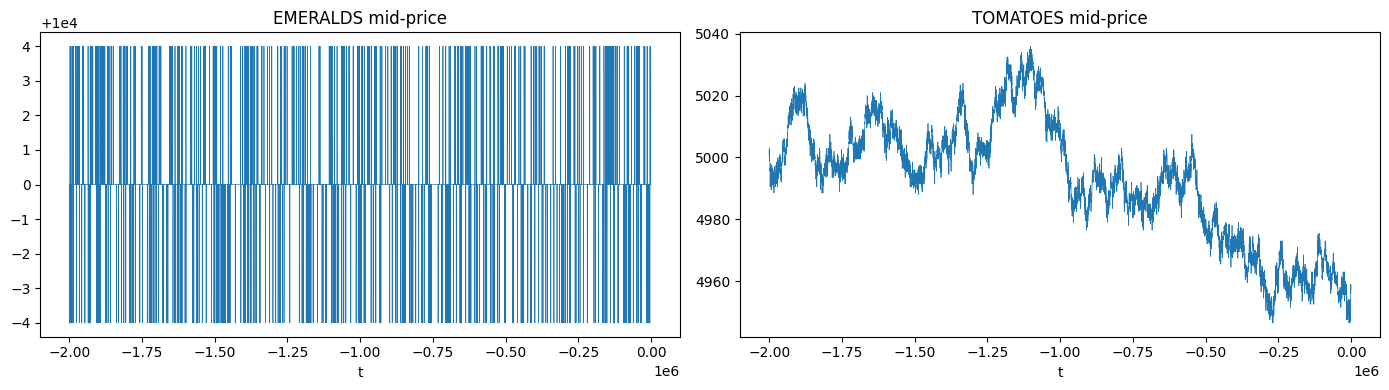

In [2]:
# Pivot mid_price into a wide DataFrame: rows = time, cols = product
mid = prices.pivot_table(index="t", columns="product", values="mid_price")
mid = mid.sort_index().ffill()

# Returns: simple difference (prices are int-scale, not percentage)
returns = mid.diff().dropna()

# Also compute log returns for comparison
log_returns = np.log(mid).diff().dropna()

print(f"Mid-price matrix: {mid.shape}")
print(f"\nReturn stats (diff):")
display(returns.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, col in enumerate(mid.columns):
    axes[i].plot(mid.index, mid[col], linewidth=0.5)
    axes[i].set_title(f"{col} mid-price")
    axes[i].set_xlabel("t")
plt.tight_layout()
plt.show()

---
## Model 1: PCA Factor Model

Extract principal components from the covariance matrix of returns. With 2 products we get 2 PCs:
- **PC1**: market-wide factor (common movement)
- **PC2**: relative-value factor (divergence between products)

This framework scales directly when more products arrive in later rounds.

In [3]:
from numpy.linalg import eigh

# Standardize returns (zero mean, unit variance) before PCA
ret_mean = returns.mean()
ret_std = returns.std()
ret_standardized = (returns - ret_mean) / ret_std

# Covariance matrix of standardized returns = correlation matrix
cov_matrix = ret_standardized.cov()
print("Covariance (correlation) matrix:")
display(cov_matrix)

# Eigendecomposition
eigenvalues, eigenvectors = eigh(cov_matrix.values)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Variance explained
var_explained = eigenvalues / eigenvalues.sum()
print(f"\nEigenvalues: {eigenvalues}")
print(f"Variance explained: {var_explained}")
print(f"Cumulative: {np.cumsum(var_explained)}")

# Loadings
loadings = pd.DataFrame(
    eigenvectors,
    index=returns.columns,
    columns=[f"PC{i+1}" for i in range(len(eigenvalues))]
)
print("\nFactor loadings:")
display(loadings)

Covariance (correlation) matrix:


product,EMERALDS,TOMATOES
product,,
EMERALDS,1.000000,-0.012803
TOMATOES,-0.012803,1.000000



Eigenvalues: [1.01280275 0.98719725]
Variance explained: [0.50640138 0.49359862]
Cumulative: [0.50640138 1.        ]

Factor loadings:


,PC1,PC2
product,,
EMERALDS,-0.707107,-0.707107
TOMATOES,0.707107,-0.707107


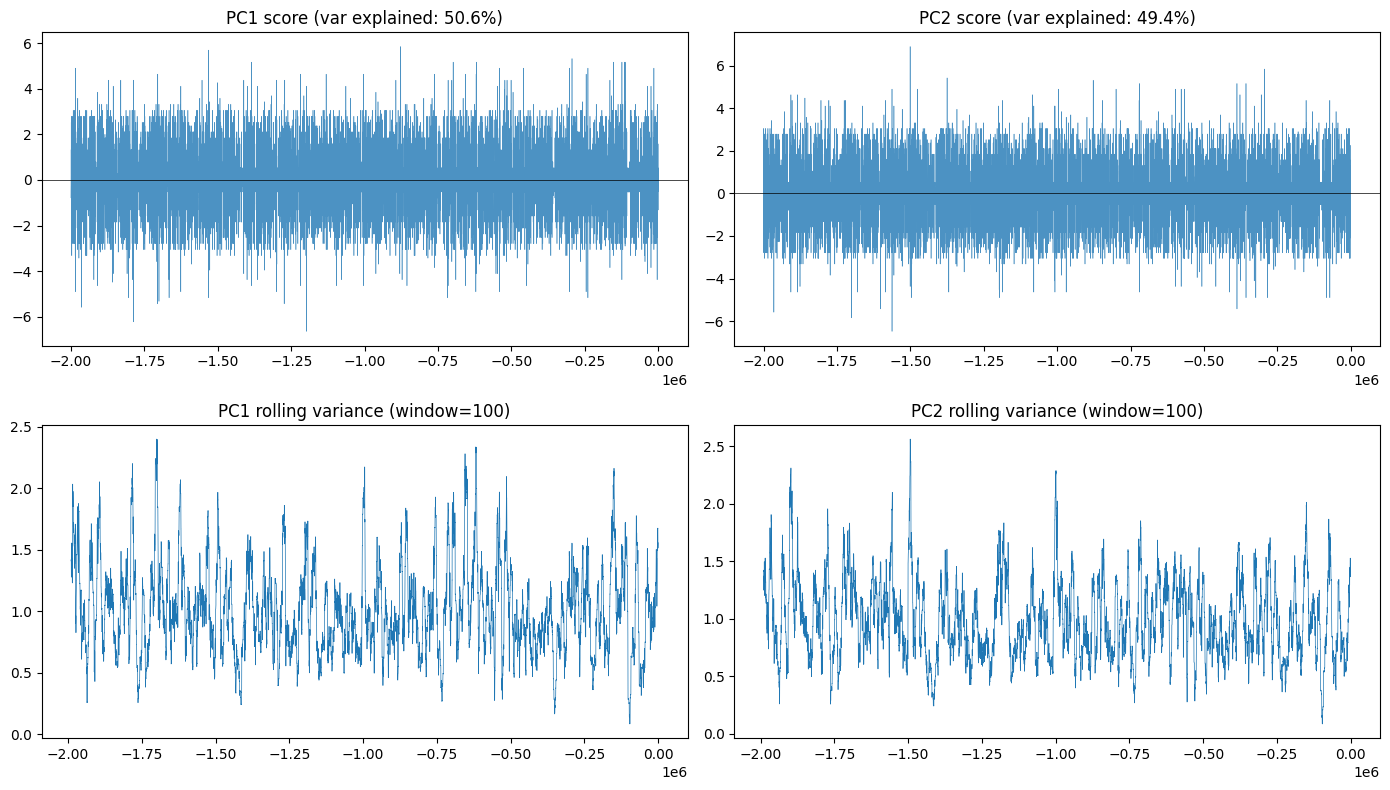

In [4]:
# Project returns onto principal components
pc_scores = ret_standardized.values @ eigenvectors
pc_df = pd.DataFrame(pc_scores, index=returns.index, columns=[f"PC{i+1}" for i in range(pc_scores.shape[1])])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# PC time series
for i in range(min(2, pc_df.shape[1])):
    axes[0, i].plot(pc_df.index, pc_df[f"PC{i+1}"], linewidth=0.4, alpha=0.8)
    axes[0, i].set_title(f"PC{i+1} score (var explained: {var_explained[i]:.1%})")
    axes[0, i].axhline(0, color="k", linewidth=0.5)

# Rolling variance of each PC (stability check)
window = 100
for i in range(min(2, pc_df.shape[1])):
    rolling_var = pc_df[f"PC{i+1}"].rolling(window).var()
    axes[1, i].plot(pc_df.index, rolling_var, linewidth=0.5)
    axes[1, i].set_title(f"PC{i+1} rolling variance (window={window})")

plt.tight_layout()
plt.show()

Using 1 factor(s):
  EMERALDS: R² = 0.5064, residual std = 0.7121
  TOMATOES: R² = 0.5064, residual std = 0.9422


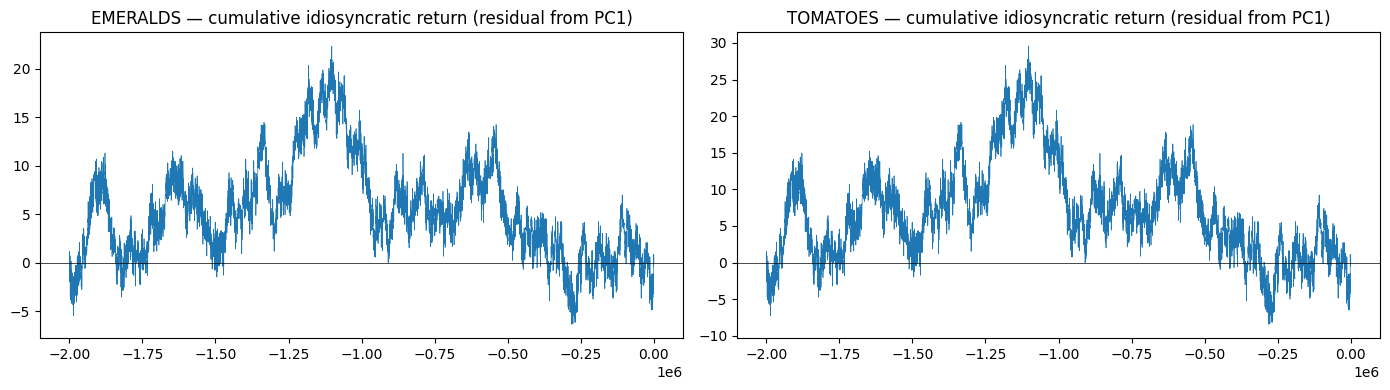

In [5]:
# Factor model reconstruction: R = B @ F + epsilon
# Using just PC1 as the single factor
n_factors = 1
B = loadings.iloc[:, :n_factors]  # loadings for selected PCs
F = pc_df.iloc[:, :n_factors]     # factor scores

# Reconstruct returns
reconstructed = (F.values @ B.values.T) * ret_std.values + ret_mean.values
residuals = returns.values - reconstructed

# Residual analysis — these are the idiosyncratic (product-specific) returns
residual_df = pd.DataFrame(residuals, index=returns.index, columns=returns.columns)

print(f"Using {n_factors} factor(s):")
for col in returns.columns:
    total_var = returns[col].var()
    resid_var = residual_df[col].var()
    r_squared = 1 - resid_var / total_var
    print(f"  {col}: R² = {r_squared:.4f}, residual std = {residual_df[col].std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, col in enumerate(returns.columns):
    axes[i].plot(returns.index, residual_df[col].cumsum(), linewidth=0.5)
    axes[i].set_title(f"{col} — cumulative idiosyncratic return (residual from PC1)")
    axes[i].axhline(0, color="k", linewidth=0.5)
plt.tight_layout()
plt.show()

---
## Model 2: Microstructure Factor Model

Use order book features as factors to predict short-term returns:
- **Volume imbalance**: (bid_vol - ask_vol) / (bid_vol + ask_vol) at each level
- **Spread**: ask_1 - bid_1
- **Weighted mid-price**: volume-weighted midpoint
- **Depth ratio**: total bid depth vs total ask depth

In [6]:
def build_microstructure_features(df):
    """Extract order-book microstructure features per row."""
    out = df[["t", "product", "mid_price"]].copy()

    # Spread
    out["spread"] = df["ask_price_1"] - df["bid_price_1"]

    # Level-1 volume imbalance
    bid1 = df["bid_volume_1"].fillna(0)
    ask1 = df["ask_volume_1"].fillna(0)
    out["imbalance_1"] = (bid1 - ask1) / (bid1 + ask1 + 1e-9)

    # Total depth imbalance (all visible levels)
    total_bid = sum(df[f"bid_volume_{i}"].fillna(0) for i in range(1, 4))
    total_ask = sum(df[f"ask_volume_{i}"].fillna(0) for i in range(1, 4))
    out["depth_imbalance"] = (total_bid - total_ask) / (total_bid + total_ask + 1e-9)

    # Weighted mid-price (volume-weighted)
    out["wmid"] = (
        df["bid_price_1"] * ask1 + df["ask_price_1"] * bid1
    ) / (bid1 + ask1 + 1e-9)
    out["wmid_deviation"] = out["wmid"] - out["mid_price"]

    # Depth at level 2 (liquidity behind best)
    out["depth_2_bid"] = df["bid_volume_2"].fillna(0)
    out["depth_2_ask"] = df["ask_volume_2"].fillna(0)

    return out

micro = build_microstructure_features(prices)
print("Microstructure features:")
display(micro.groupby("product").describe().T)

Microstructure features:


product                EMERALDS      TOMATOES
t           count  2.000000e+04  2.000000e+04
            mean  -1.000050e+06 -1.000050e+06
            std    5.773647e+05  5.773647e+05
            min   -2.000000e+06 -2.000000e+06
            25%   -1.500025e+06 -1.500025e+06
...                         ...           ...
depth_2_ask min    1.000000e+01  5.000000e+00
            25%    2.200000e+01  1.700000e+01
            50%    2.500000e+01  2.000000e+01
            75%    2.800000e+01  2.300000e+01
            max    3.000000e+01  2.500000e+01

[72 rows x 2 columns]

In [7]:
from numpy.linalg import lstsq

# For each product: regress next-step return on microstructure factors
factor_cols = ["imbalance_1", "depth_imbalance", "spread", "wmid_deviation"]

results = {}
for product in micro["product"].unique():
    pm = micro[micro["product"] == product].sort_values("t").copy()
    pm["fwd_return"] = pm["mid_price"].diff().shift(-1)  # next-step return
    pm = pm.dropna(subset=["fwd_return"] + factor_cols)

    X = pm[factor_cols].values
    X = np.column_stack([X, np.ones(len(X))])  # add intercept
    y = pm["fwd_return"].values

    coefs, residuals_sum, rank, sv = lstsq(X, y, rcond=None)

    y_hat = X @ coefs
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    coef_names = factor_cols + ["intercept"]
    coef_df = pd.DataFrame({"coef": coefs, "factor": coef_names}).set_index("factor")

    results[product] = {"coefs": coef_df, "r2": r2, "n": len(y), "pm": pm, "y_hat": y_hat, "y": y}

    print(f"\n=== {product} ===")
    print(f"R² = {r2:.6f}  (n={len(y)})")
    display(coef_df)


=== TOMATOES ===
R² = 0.385520  (n=19999)


,coef
factor,
imbalance_1,6.364910
depth_imbalance,-27.109808
spread,-0.024904
wmid_deviation,-0.850011
intercept,0.318688



=== EMERALDS ===
R² = 0.489193  (n=19999)


,coef
factor,
imbalance_1,48329.488149
depth_imbalance,-29.640474
spread,-0.001270
wmid_deviation,-12081.180406
intercept,0.012925


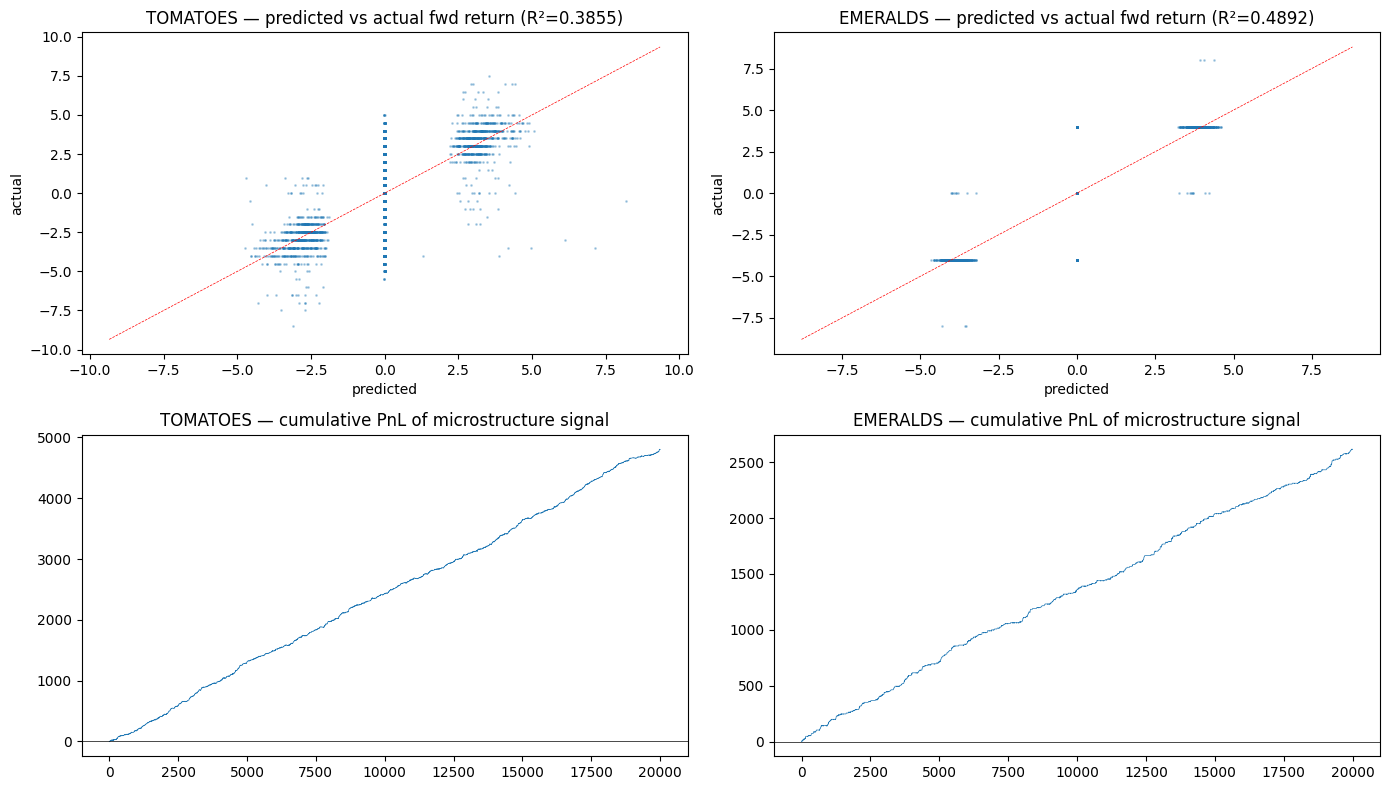

In [8]:
# Visualize microstructure factor signal vs realized returns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, product in enumerate(results):
    r = results[product]
    pm = r["pm"]

    # Scatter: predicted vs actual
    axes[0, i].scatter(r["y_hat"], r["y"], s=1, alpha=0.3)
    axes[0, i].set_title(f"{product} — predicted vs actual fwd return (R²={r['r2']:.4f})")
    axes[0, i].set_xlabel("predicted")
    axes[0, i].set_ylabel("actual")
    lim = max(abs(r["y_hat"]).max(), abs(r["y"]).max()) * 1.1
    axes[0, i].plot([-lim, lim], [-lim, lim], "r--", linewidth=0.5)

    # Cumulative PnL of the factor signal
    # Trade: go long if predicted return > 0, short if < 0, size = 1
    signal = np.sign(r["y_hat"])
    pnl = np.cumsum(signal * r["y"])
    axes[1, i].plot(pnl, linewidth=0.5)
    axes[1, i].set_title(f"{product} — cumulative PnL of microstructure signal")
    axes[1, i].axhline(0, color="k", linewidth=0.5)

plt.tight_layout()
plt.show()

---
## Model 3: Momentum / Mean-Reversion Factor Model

Autoregressive features to capture short-term predictability:
- **Lagged returns** (1, 5, 20 steps)
- **Rolling volatility**
- **Z-score** of price vs rolling mean (mean-reversion signal)
- **Return autocorrelation** (rolling)

In [9]:
def build_momentum_features(mid_series, product_name):
    """Build momentum/mean-reversion features from a mid-price series."""
    df = pd.DataFrame({"mid": mid_series})
    df["ret_1"] = df["mid"].diff(1)
    df["ret_5"] = df["mid"].diff(5)
    df["ret_20"] = df["mid"].diff(20)

    # Rolling volatility
    df["vol_20"] = df["ret_1"].rolling(20).std()
    df["vol_50"] = df["ret_1"].rolling(50).std()

    # Z-score: how far is price from rolling mean
    df["ma_20"] = df["mid"].rolling(20).mean()
    df["ma_50"] = df["mid"].rolling(50).mean()
    df["zscore_20"] = (df["mid"] - df["ma_20"]) / (df["vol_20"] + 1e-9)
    df["zscore_50"] = (df["mid"] - df["ma_50"]) / (df["vol_50"] + 1e-9)

    # Rolling autocorrelation of returns (lag 1)
    df["autocorr_20"] = df["ret_1"].rolling(20).apply(lambda x: x.autocorr(lag=1), raw=False)

    # Forward return (target)
    df["fwd_return"] = df["ret_1"].shift(-1)

    df["product"] = product_name
    return df

mom_features = []
for col in mid.columns:
    mf = build_momentum_features(mid[col], col)
    mom_features.append(mf)

mom_all = pd.concat(mom_features)
print("Momentum features:")
display(mom_all.groupby("product")[["ret_1", "ret_5", "zscore_20", "zscore_50", "autocorr_20"]].describe().T)

Momentum features:


product                EMERALDS      TOMATOES
ret_1       count  19999.000000  19999.000000
            mean       0.000000     -0.002150
            std        1.013559      1.341035
            min       -8.000000     -8.500000
            25%        0.000000     -0.500000
            50%        0.000000      0.000000
            75%        0.000000      0.500000
            max        8.000000      7.500000
ret_5       count  19995.000000  19995.000000
            mean       0.000000     -0.010878
            std        1.023872      1.693393
            min       -8.000000     -8.000000
            25%        0.000000     -1.000000
            50%        0.000000      0.000000
            75%        0.000000      1.000000
            max        8.000000      9.500000
zscore_20   count  19980.000000  19980.000000
            mean       0.000176     -0.009943
            std        0.637949      1.534519
            min       -4.248529    -10.601752
            25%        0.000000     -0.770552
            50%        0.000000      0.000000
            75%        0.000000      0.754549
            max        4.248529     10.499246
zscore_50   count  19950.000000  19950.000000
            mean      -0.001960     -0.045677
            std        0.778439      1.848294
            min       -6.929646    -12.499974
            25%       -0.098995     -1.136491
            50%        0.000000     -0.032939
            75%        0.098995      1.075853
            max        6.929646      8.103911
autocorr_20 count   9261.000000  19980.000000
            mean      -0.501396     -0.350496
            std        0.119214      0.217564
            min       -0.899501     -0.903571
            25%       -0.500000     -0.498535
            50%       -0.500000     -0.394779
            75%       -0.500000     -0.238772
            max        0.055556      0.571125

In [10]:
# Regress forward return on momentum/mean-reversion factors
mom_factor_cols = ["ret_1", "ret_5", "ret_20", "zscore_20", "zscore_50", "autocorr_20", "vol_20"]

mom_results = {}
for product in mid.columns:
    pm = mom_all[mom_all["product"] == product].dropna(subset=mom_factor_cols + ["fwd_return"]).copy()

    X = pm[mom_factor_cols].values
    # Standardize features
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0) + 1e-9
    X_norm = (X - X_mean) / X_std
    X_norm = np.column_stack([X_norm, np.ones(len(X_norm))])
    y = pm["fwd_return"].values

    coefs, _, _, _ = lstsq(X_norm, y, rcond=None)
    y_hat = X_norm @ coefs
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    coef_names = mom_factor_cols + ["intercept"]
    coef_df = pd.DataFrame({"coef": coefs, "factor": coef_names}).set_index("factor")

    mom_results[product] = {"coefs": coef_df, "r2": r2, "n": len(y), "y_hat": y_hat, "y": y}

    print(f"\n=== {product} ===")
    print(f"R² = {r2:.6f}  (n={len(y)})")
    display(coef_df)


=== EMERALDS ===
R² = 0.461168  (n=9230)


,coef
factor,
ret_1,-0.019429
ret_5,-0.025309
ret_20,-0.059545
zscore_20,-0.050386
zscore_50,-0.571319
autocorr_20,0.006321
vol_20,0.012580
intercept,-0.001733



=== TOMATOES ===
R² = 0.207884  (n=19949)


,coef
factor,
ret_1,-0.440950
ret_5,-0.227861
ret_20,-0.077698
zscore_20,0.024335
zscore_50,-0.015435
autocorr_20,0.023420
vol_20,0.032459
intercept,-0.001880


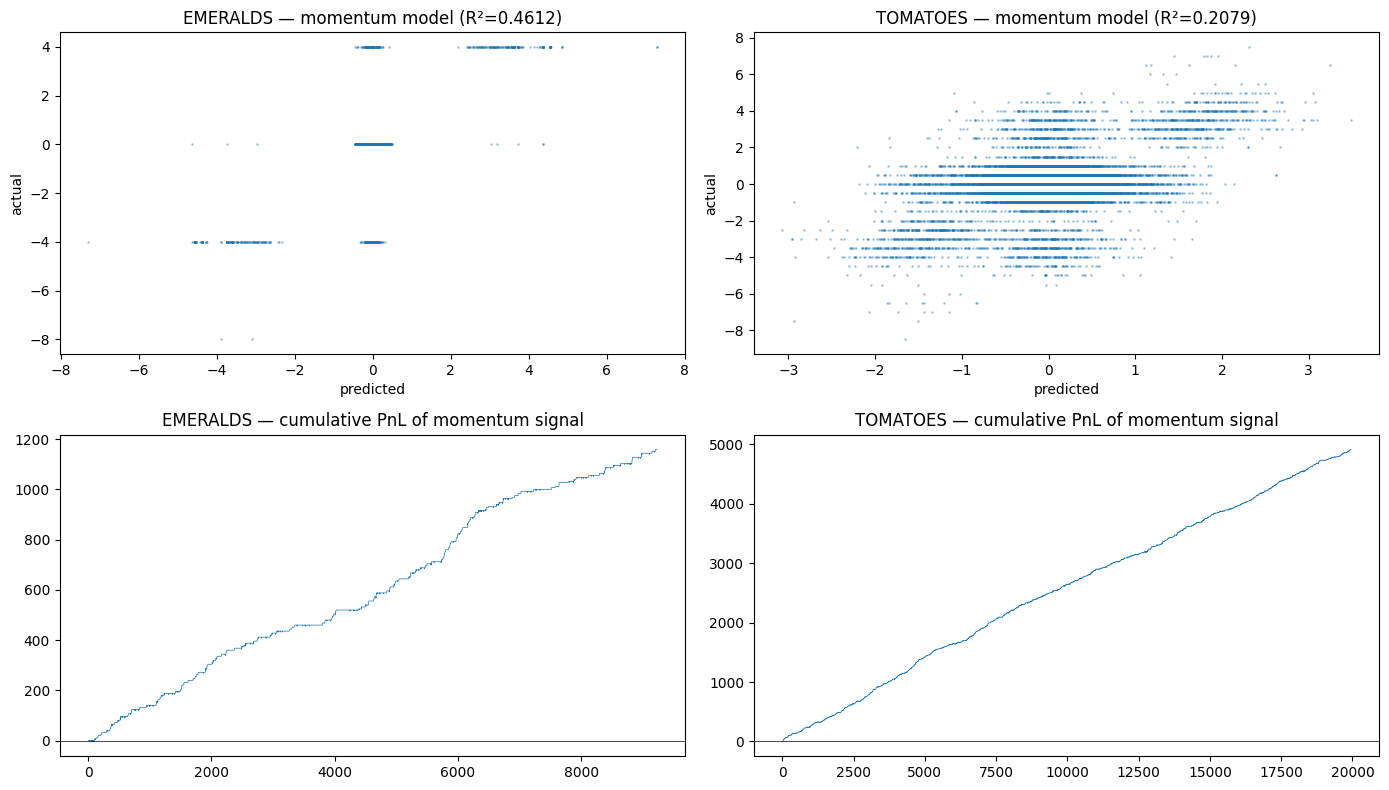

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, product in enumerate(mom_results):
    r = mom_results[product]

    # Scatter
    axes[0, i].scatter(r["y_hat"], r["y"], s=1, alpha=0.3)
    axes[0, i].set_title(f"{product} — momentum model (R²={r['r2']:.4f})")
    axes[0, i].set_xlabel("predicted")
    axes[0, i].set_ylabel("actual")

    # Cumulative PnL
    signal = np.sign(r["y_hat"])
    pnl = np.cumsum(signal * r["y"])
    axes[1, i].plot(pnl, linewidth=0.5)
    axes[1, i].set_title(f"{product} — cumulative PnL of momentum signal")
    axes[1, i].axhline(0, color="k", linewidth=0.5)

plt.tight_layout()
plt.show()

---
## Model Comparison

In-sample R² comparison:


model,Microstructure,Momentum/MR,PCA (1 factor)
product,,,
EMERALDS,0.489193,0.461168,0.506401
TOMATOES,0.385520,0.207884,0.506401


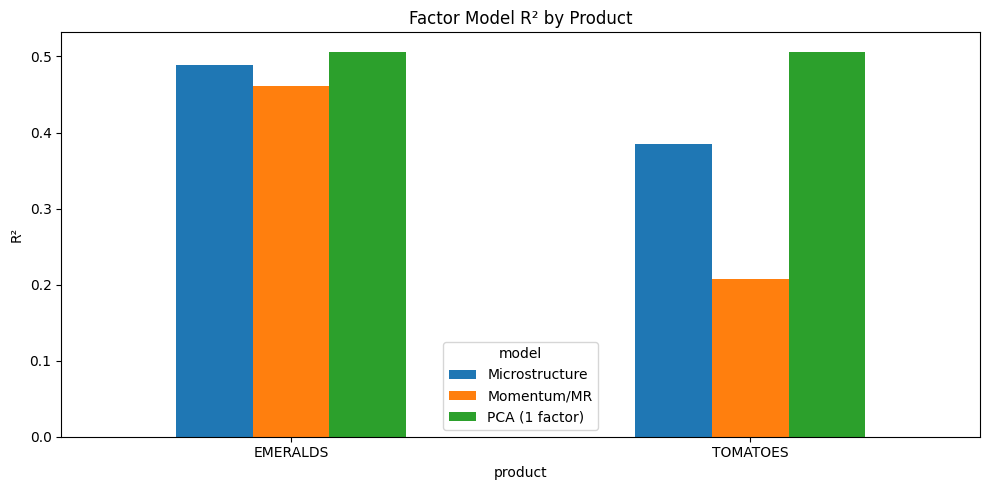

In [12]:
# Summary comparison
summary_rows = []

# PCA R² (from model 1 — in-sample)
for col in returns.columns:
    total_var = returns[col].var()
    resid_var = residual_df[col].var()
    r2 = 1 - resid_var / total_var
    summary_rows.append({"product": col, "model": "PCA (1 factor)", "R²": r2})

# Microstructure
for product, r in results.items():
    summary_rows.append({"product": product, "model": "Microstructure", "R²": r["r2"]})

# Momentum
for product, r in mom_results.items():
    summary_rows.append({"product": product, "model": "Momentum/MR", "R²": r["r2"]})

summary = pd.DataFrame(summary_rows)
comparison = summary.pivot(index="product", columns="model", values="R²")
print("In-sample R² comparison:")
display(comparison)

comparison.plot(kind="bar", figsize=(10, 5), title="Factor Model R² by Product")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


=== TOMATOES (OOS: day -1) ===
R² = 0.374548
Directional accuracy = 0.3728
Cumulative PnL = 2369.00

=== EMERALDS (OOS: day -1) ===
R² = 0.484406
Directional accuracy = 0.0470
Cumulative PnL = 1296.00


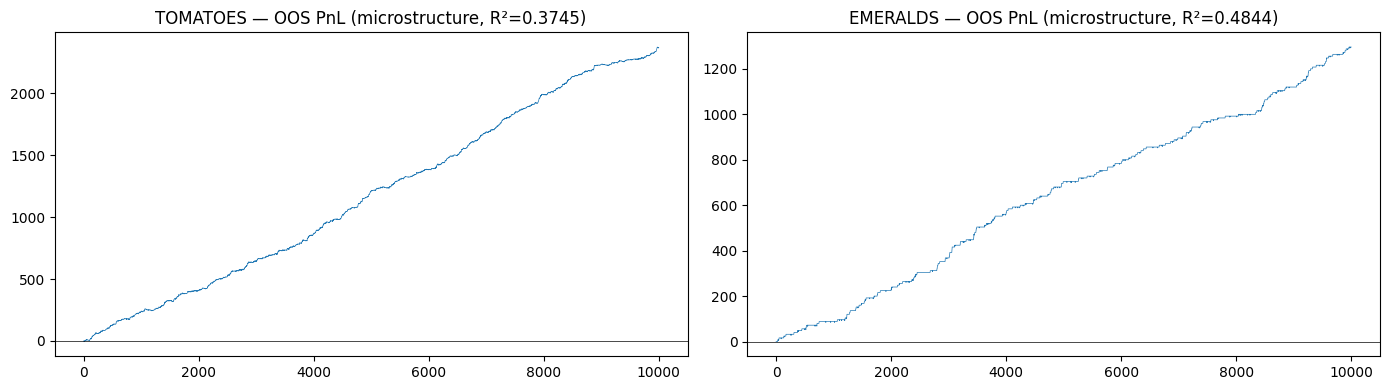

In [13]:
# Out-of-sample check: train on day -2, test on day -1
# Using the microstructure model as an example

day2_mask = prices["day"] == -2
day1_mask = prices["day"] == -1

micro_train = build_microstructure_features(prices[day2_mask])
micro_test = build_microstructure_features(prices[day1_mask])

oos_results = {}
for product in micro["product"].unique():
    train = micro_train[micro_train["product"] == product].sort_values("t").copy()
    test = micro_test[micro_test["product"] == product].sort_values("t").copy()

    train["fwd_return"] = train["mid_price"].diff().shift(-1)
    test["fwd_return"] = test["mid_price"].diff().shift(-1)

    train = train.dropna(subset=["fwd_return"] + factor_cols)
    test = test.dropna(subset=["fwd_return"] + factor_cols)

    # Fit on train
    X_train = np.column_stack([train[factor_cols].values, np.ones(len(train))])
    y_train = train["fwd_return"].values
    coefs, _, _, _ = lstsq(X_train, y_train, rcond=None)

    # Predict on test
    X_test = np.column_stack([test[factor_cols].values, np.ones(len(test))])
    y_test = test["fwd_return"].values
    y_hat_test = X_test @ coefs

    ss_res = np.sum((y_test - y_hat_test) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2_oos = 1 - ss_res / ss_tot

    # Directional accuracy
    direction_correct = np.mean(np.sign(y_hat_test) == np.sign(y_test))

    # PnL
    pnl = np.cumsum(np.sign(y_hat_test) * y_test)

    oos_results[product] = {
        "r2_oos": r2_oos,
        "direction_accuracy": direction_correct,
        "pnl": pnl,
        "total_pnl": pnl[-1]
    }

    print(f"\n=== {product} (OOS: day -1) ===")
    print(f"R² = {r2_oos:.6f}")
    print(f"Directional accuracy = {direction_correct:.4f}")
    print(f"Cumulative PnL = {pnl[-1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, (product, r) in enumerate(oos_results.items()):
    axes[i].plot(r["pnl"], linewidth=0.5)
    axes[i].set_title(f"{product} — OOS PnL (microstructure, R²={r['r2_oos']:.4f})")
    axes[i].axhline(0, color="k", linewidth=0.5)
plt.tight_layout()
plt.show()

---
## Key Takeaways

**Interpretation notes:**
- With only 2 products, PCA is mostly confirming that EMERALDS is stationary and TOMATOES drives variance.
- The PCA framework becomes powerful when more products arrive in later rounds — basket arb (round 2) and multi-product (round 5) are prime targets.
- Microstructure factors (especially volume imbalance) may give actionable short-term alpha for market making.
- Momentum/MR z-scores are the natural signal for the adaptive MM on TOMATOES.
- **Check OOS R² carefully** — low or negative R² OOS means overfitting.

**Next steps:**
1. Integrate promising factors into `trader.py` fair-value estimation
2. Re-run this notebook as new round data becomes available (more products = richer PCA)
3. Test combined signals (microstructure + momentum ensemble)